### Una vez limpio el dataset, realizaremos un Análisis Exploratorio de Datos (EDA) para identificar los factores que más influyen en el precio de los vehículos y detectar oportunidades de mercado.

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el CSV limpio
df = pd.read_csv('mazda3_limpio.csv')

# Verificar que las columnas numéricas estén bien
print(df.info())

df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   precio       113 non-null    float64
 1   año          168 non-null    int64  
 2   kilometros   168 non-null    int64  
 3   motor        168 non-null    float64
 4   transmision  168 non-null    object 
 5   carroceria   168 non-null    object 
 6   version      168 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 9.3+ KB
None


,precio,año,kilometros,motor,transmision,carroceria,version
0,320999.0,2022,17392,2.0,automático,sedán,i sport
1,276999.0,2022,35149,2.5,automático,sedán,i (base)
2,326999.0,2022,53233,2.5,automático,sedán,turbo signature 4wd
3,213999.0,2017,58273,2.5,automático,hatchback,s grand touring
4,176999.0,2018,122213,2.0,manual,sedán,i (base)
5,278999.0,2022,101587,2.5,manual,sedán,i sport
6,287999.0,2021,37507,2.5,automático,sedán,i sport
7,322999.0,2022,25600,2.5,automático,sedán,i sport
8,248999.0,2018,23526,2.5,manual,sedán,s
9,200999.0,2015,35851,2.0,automático,sedán,i (base)


### La información esta correcta, con respecto al tipo de datos y al df en general, proseguimos a realizar las gráficas.

# Gráfica de Dispersión: Precio vs. Kilometraje

### Objetivo: Visualizar la devaluación y cómo se agrupan las versiones.

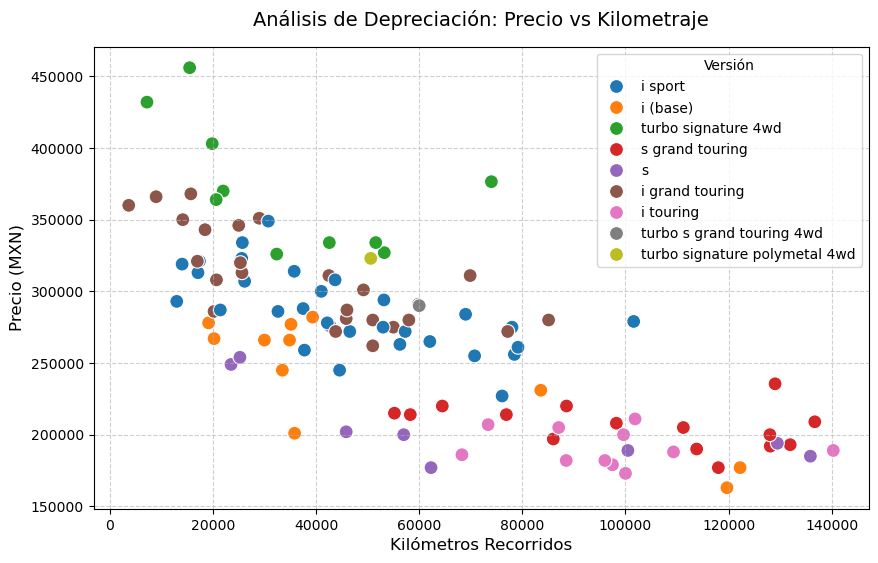

In [13]:
plt.figure(figsize=(10, 6))

# Usamos Seaborn para darle estilo y separar por versión
sns.scatterplot(data=df, x='kilometros', y='precio', hue='version', s=100) # Tomamos las columnas kilometros y precio del df, y version

# Personalización 
plt.title('Análisis de Depreciación: Precio vs Kilometraje', fontsize=14, pad=15) # Titulo
plt.xlabel('Kilómetros Recorridos', fontsize=12)                                  # Etiqueta eje X
plt.ylabel('Precio (MXN)', fontsize=12)                                           # Etiqueta eje Y
plt.legend(title='Versión', bbox_to_anchor=(1, 1))                                # Etiqueta de leyenda
plt.grid(True, linestyle='--', alpha=0.6)                                         # Estilo de linea y transparencia 

plt.show()

### Deducción: Existe una correlación negativa clara: a mayor kilometraje, menor precio. Notamos que la versión Turbo Signature 4WD domina el rango alto de precios, mientras que el i Touring se mantiene como la opción más accesible.

# Análisis de Distribución: Precios por versión
### Objetivo: Observar el precio promedio por versión.

C:\Users\carlo\AppData\Local\Temp\ipykernel_17208\2279343241.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='precio', y='version', palette='viridis', order=order)       # Tomamos columnas precio y version  con las barras hechas anteriormente


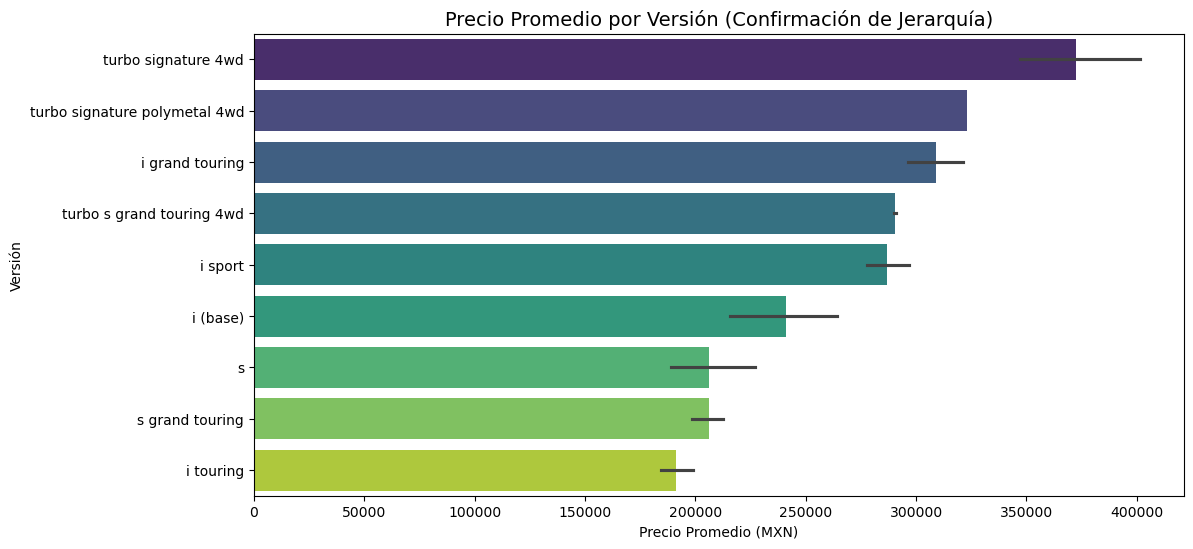

In [14]:
plt.figure(figsize=(12, 6))

# Calculamos el promedio y graficamos
# 'order' sirve para que las barras salgan de mayor a menor precio
order = df.groupby("version")["precio"].mean().sort_values(ascending=False).index   # Tomamos el groupby para agrupar por version y mostrarlo en la grafica mediante barras

sns.barplot(data=df, x='precio', y='version', palette='viridis', order=order)       # Tomamos columnas precio y version  con las barras hechas anteriormente

# Personalización
plt.title('Precio Promedio por Versión (Confirmación de Jerarquía)', fontsize=14)
plt.xlabel('Precio Promedio (MXN)')
plt.ylabel('Versión')

plt.show()

### Deducción: Confirmamos lo visto en la gráfica anterior:  la versión Turbo Signature 4WD domina el rango alto de precios, totalmente entendible al ser el tope de gama con motor turbo y tracción integral mientras que el i Touring se mantiene como la opción más accesible.

# Análisis de Distribución: Precios por Año (Boxplot)
### Objetivo: Observar el rango de precios anual y detectar valores atípicos (ofertas).

C:\Users\carlo\AppData\Local\Temp\ipykernel_17208\80533129.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='año', y='precio', palette='magma') # Tomamos la información del df, columnas año y precio


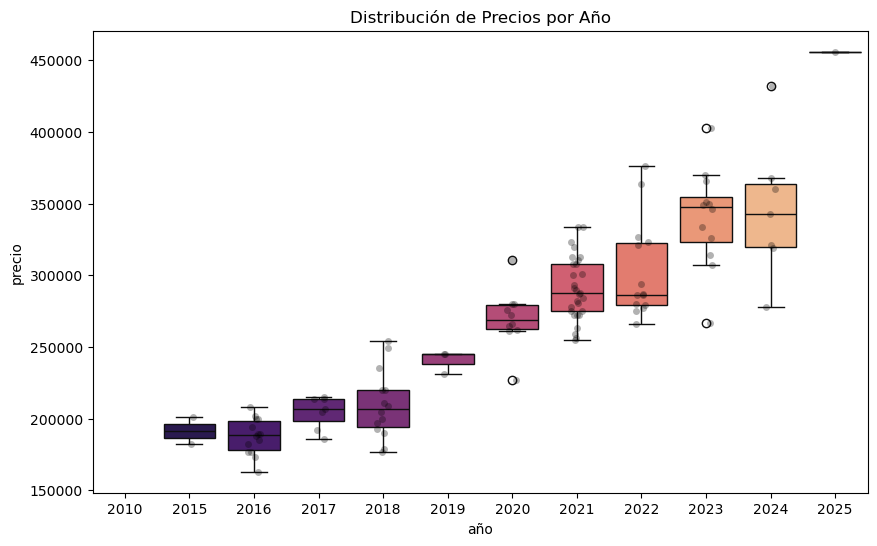

In [15]:
plt.figure(figsize=(10, 6)) # Tamaño de gráfica
sns.boxplot(data=df, x='año', y='precio', palette='magma') # Tomamos la información del df, columnas año y precio
sns.stripplot(data=df, x='año', y='precio', color='black', alpha=0.3) # Ver los puntos reales

plt.title('Distribución de Precios por Año')
plt.show()

### Deducción: El año es un factor determinante. Detectamos un valor atípico en 2020: un vehículo con un precio significativamente menor al promedio de su año, lo que representa una oportunidad potencial de compra. PD: Algún día me compraré un Mazda 3.

# Mapa de Calor: Correlaciones Numéricas
### Objetivo: Cuantificar matemáticamente la relación entre las variables.

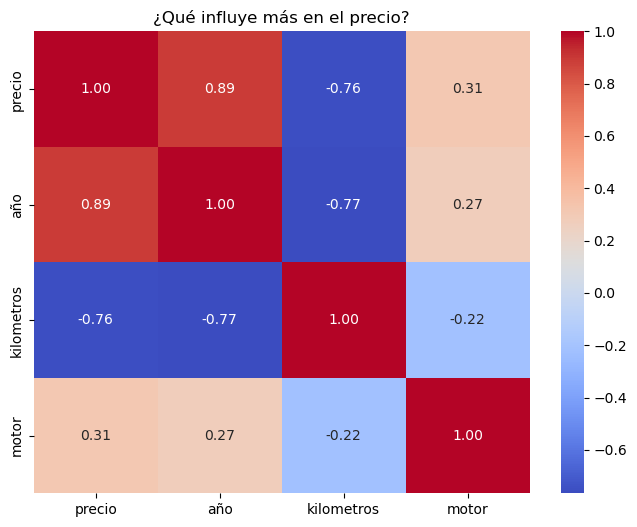

In [16]:
plt.figure(figsize=(8, 6))
# Solo columnas numéricas
corr = df[['precio', 'año', 'kilometros', 'motor']].corr() # Aquí utilizamos la funcion corr
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f") # Mostramos el valor numérico de la correlación, la paleta de colores tipo coolwarm y formato de mostrar los números
plt.title('¿Qué influye más en el precio?')
plt.show()

## Deducción:  Año vs Precio (0.89): Relación positiva muy fuerte; es el factor que más influye.

### Kilómetros vs Precio (-0.76): Relación negativa fuerte; el uso reduce el valor de forma constante.

### Motor (0.31): Tiene un impacto positivo, pero es secundario frente al año y uso.

# Conclusión General
## El mercado de Mazda 3 en esta muestra está impulsado principalmente por la antigüedad del modelo. Para un comprador que busca valor, los modelos 2020 con precios por debajo de los $230,000 MXN son las mejores opciones calidad-precio, rompiendo la tendencia normal de depreciación.